### Tekoälyn käyttö

Tässä työssä ChatGPT:tä käytettiin apuna koodin sekä tekstiselitysten kirjoittamisessa.  
Työn tekijä tarkisti tulokset (kuvaajat, taulukot ja mittarit) ja varmisti, että tekstiosuudet vastaavat laskennan tuottamia tuloksia.

Työn tekijä vastaa työn lopullisesta versiosta ja sen sisällöstä.

# 1. Business Understanding

Tässä tehtävässä tarkastellaan drone-toimitusyrityksen dataa kahdesta näkökulmasta:
1) depotien (hubien) sijoittelu asiakaskoordinanttien perusteella
2) tuoteryhmien yhteisostaminen (association rules), jotta voidaan tehdä suosituksia

Työ tehdään CRISP-DM-mallin mukaan. Menetelminä käytetään luennoilla käsiteltyjä: k-means, agglomerative clustering sekä Apriori + association rules.

# 2. Data Understanding

Yhdistämme kirjastot datan käsittelyä, visualisointia, ajan mittausta, klusterointia sekä association rules -analyysia varten.
Määritämme polut kahteen CSV-tiedostoon sekä kaksi avainparametria: N_DEPOTS (kuinka monta depota/klusteria haluamme) ja RANDOM_STATE (jotta tulokset ovat toistettavia jokaisella ajokerralla).

In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from mlxtend.frequent_patterns import apriori, association_rules

LOC_PATH = "drone_cust_locations.csv"
PROD_PATH = "drone_prod_groups.csv"

N_DEPOTS = 3
RANDOM_STATE = 42

Lataamme tiedoston, jossa on asiakkaiden koordinaatit.
Tarkistamme heti perusasiat: taulukon koon, ensimmäiset rivit, sarakkeiden tietotyypit sekä puuttuvien arvojen esiintymisen.
Tämän tarkoitus on varmistaa, että data on luettu oikein ja soveltuu klusterointiin.

In [196]:
df_loc = pd.read_csv(LOC_PATH, sep=';')

print("df_loc shape:", df_loc.shape)
display(df_loc.head())

df_loc.info()
print("\nMissing values:")
print(df_loc.isna().sum())

df_loc shape: (5956, 3)


,clientid,x,y
0,1,622.771572,164.857623
1,2,416.357298,630.193634
2,3,292.735020,567.333231
3,4,737.211288,166.225676
4,5,540.475375,682.912298


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5956 entries, 0 to 5955
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   clientid  5956 non-null   int64  
 1   x         5956 non-null   float64
 2   y         5956 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 139.7 KB

Missing values:
clientid    0
x           0
y           0
dtype: int64


Piirrämme scatterplotin x- ja y-muuttujista nähdäksemme, miten asiakkaat jakautuvat tasolla.
Näin on helpompi arvioida etukäteen, muodostuuko “ryppäitä” (mahdollisia klustereita) ja onko järkevää käyttää k-means- tai hierarkkista klusterointia.

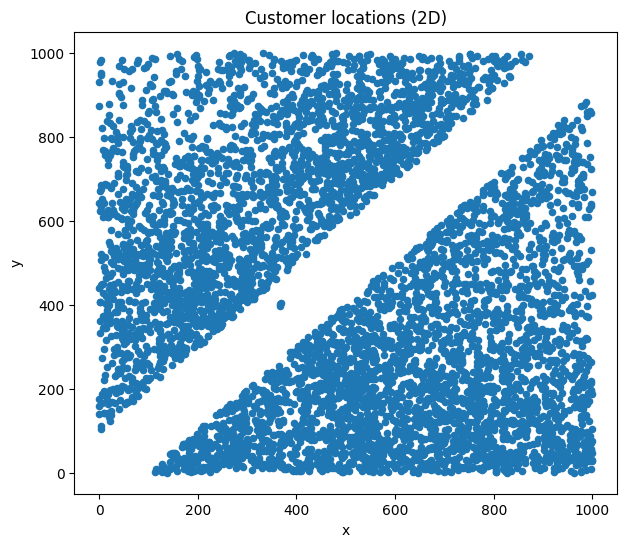

In [197]:
plt.figure(figsize=(7, 6))
plt.scatter(df_loc["x"], df_loc["y"], s=20)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Customer locations (2D)")
plt.show()

Data latautui oikein: 5956 riviä ja 3 saraketta (clientid, x, y). Puuttuvia arvoja ei ole ja x/y ovat numeerisia, joten data sopii klusterointiin.  
Scatterplotissa pisteet jakautuvat epätasaisesti ja muodostavat kaksi selkeämpää aluetta, joiden välissä on tyhjempi vyöhyke. Tämä viittaa siihen, että klusterointi on järkevä lähestymistapa.

Lataamme transaktiot tuoteryhmittäin.
Tarkistamme samalla tavalla koon, ensimmäiset rivit, tietotyypit ja puuttuvat arvot - jotta voimme olla varmoja datan oikeellisuudesta ennen Apriori-/association rules -analyysia.

In [198]:
df_prod = pd.read_csv(PROD_PATH)
df_prod.columns = df_prod.columns.str.strip()

print("df_prod shape:", df_prod.shape)
display(df_prod.head())

df_prod.info()
print("\nMissing values:")
print(df_prod.isna().sum())

df_prod shape: (100000, 21)


,ID,Prod1,Prod2,Prod3,Prod4,Prod5,Prod6,Prod7,Prod8,Prod9,...,Prod11,Prod12,Prod13,Prod14,Prod15,Prod16,Prod17,Prod18,Prod19,Prod20
0,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
1,2,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,1,1,1,1,1
2,3,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,1
3,4,1,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,1
4,5,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,1,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   ID      100000 non-null  int64
 1   Prod1   100000 non-null  int64
 2   Prod2   100000 non-null  int64
 3   Prod3   100000 non-null  int64
 4   Prod4   100000 non-null  int64
 5   Prod5   100000 non-null  int64
 6   Prod6   100000 non-null  int64
 7   Prod7   100000 non-null  int64
 8   Prod8   100000 non-null  int64
 9   Prod9   100000 non-null  int64
 10  Prod10  100000 non-null  int64
 11  Prod11  100000 non-null  int64
 12  Prod12  100000 non-null  int64
 13  Prod13  100000 non-null  int64
 14  Prod14  100000 non-null  int64
 15  Prod15  100000 non-null  int64
 16  Prod16  100000 non-null  int64
 17  Prod17  100000 non-null  int64
 18  Prod18  100000 non-null  int64
 19  Prod19  100000 non-null  int64
 20  Prod20  100000 non-null  int64
dtypes: int64(21)
memory usage: 16.0 MB

Missing values:
ID   

Valitsemme sarakkeet Prod1–Prod20 ja varmistamme, että niitä on todella 20.
Sen jälkeen tarkistamme kunkin sarakkeen uniikit arvot varmistaaksemme, että kyseessä ovat binääriset piirteet (0/1).
Tämä on tärkeää, koska Apriori perustuu logiikkaan “tuoteryhmä on / ei ole mukana transaktiossa”.

In [199]:
prod_cols = [c for c in df_prod.columns if 'Prod' in c]
print("Number of product columns:", len(prod_cols))
print("Product columns:", prod_cols)

for c in prod_cols:
    print(c, sorted(df_prod[c].dropna().unique()))

Number of product columns: 20
Product columns: ['Prod1', 'Prod2', 'Prod3', 'Prod4', 'Prod5', 'Prod6', 'Prod7', 'Prod8', 'Prod9', 'Prod10', 'Prod11', 'Prod12', 'Prod13', 'Prod14', 'Prod15', 'Prod16', 'Prod17', 'Prod18', 'Prod19', 'Prod20']
Prod1 [np.int64(0), np.int64(1)]
Prod2 [np.int64(0), np.int64(1)]
Prod3 [np.int64(0), np.int64(1)]
Prod4 [np.int64(0), np.int64(1)]
Prod5 [np.int64(0), np.int64(1)]
Prod6 [np.int64(0), np.int64(1)]
Prod7 [np.int64(0), np.int64(1)]
Prod8 [np.int64(0), np.int64(1)]
Prod9 [np.int64(0), np.int64(1)]
Prod10 [np.int64(0), np.int64(1)]
Prod11 [np.int64(0), np.int64(1)]
Prod12 [np.int64(0), np.int64(1)]
Prod13 [np.int64(0), np.int64(1)]
Prod14 [np.int64(0), np.int64(1)]
Prod15 [np.int64(0), np.int64(1)]
Prod16 [np.int64(0), np.int64(1)]
Prod17 [np.int64(0), np.int64(1)]
Prod18 [np.int64(0), np.int64(1)]
Prod19 [np.int64(0), np.int64(1)]
Prod20 [np.int64(0), np.int64(1)]


Transaktiodata latautui oikein: 100000 riviä ja 21 saraketta (ID + 20 tuoteryhmää). Puuttuvia arvoja ei ole.  
Kaikkien tuoteryhmäsarakkeiden arvot ovat 0/1, eli ne kuvaavat selkeästi, onko tuoteryhmä mukana ostoksessa. Data sopii Apriori- ja assosiaatiosääntöanalyysiin.

# 3. Data Preparation

Tässä vaiheessa valmistellaan data mallinnusta varten.
Klusterointia varten otamme vain koordinaatit x ja y ja kokoamme ne muuttujaan X_locations - tämä toimii syötteenä k-means- ja agglomerative-menetelmille.
Apriori-analyysiä varten teemme kopion transaktiodatasta, poistamme ID-sarakkeen (se on vain tunniste, ei tuote) ja muutamme arvot 0/1 muotoon True/False, jotta data vastaa logiikkaa “tuoteryhmä on / ei ole transaktiossa”.

In [200]:
X_locations = df_loc[["x", "y"]].copy()

df_prod_apr = df_prod.copy()

if "ID" in df_prod_apr.columns:
    df_prod_apr = df_prod_apr.drop(columns=["ID"])

df_prod_apr = df_prod_apr.astype(bool)

display(df_prod_apr.head())
print(df_prod_apr.dtypes.value_counts())

,Prod1,Prod2,Prod3,Prod4,Prod5,Prod6,Prod7,Prod8,Prod9,Prod10,Prod11,Prod12,Prod13,Prod14,Prod15,Prod16,Prod17,Prod18,Prod19,Prod20
0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True
1,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,True,True,True,True,True
2,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,True
3,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True
4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,True


bool    20
Name: count, dtype: int64


Klusterointia varten muodostettiin piirre-matriisi kahdesta koordinaatista (x, y).  
Apriori-analyysiä varten poistettiin ID-sarake ja tuoteryhmädata muunnettiin True/False-muotoon. Tarkistus vahvisti, että kaikki 20 tuoteryhmäsaraketta ovat boolean-tyyppiä, joten data on valmis frequent itemsets- ja sääntöanalyysiin.

# 4. Modeling

### Osa 1A

Suoritamme k-means-klusteroinnin käyttäen klusterien määränä N_DEPOTS, jotta asiakkaat jaetaan ryhmiin ja ryhmien keskipisteet löydetään.
Näitä keskipisteitä (centroids) voidaan käyttää arvioituina depot-sijainteina.

In [201]:
kmeans = KMeans(
    n_clusters=N_DEPOTS,
    init="random",
    random_state=RANDOM_STATE
)

kmeans.fit(X_locations)

labels_kmeans = kmeans.labels_
centers_kmeans = kmeans.cluster_centers_

print("K-means fitted.")
print("Number of depots (clusters):", N_DEPOTS)
print("Depot centers (x, y):")
print(centers_kmeans)

K-means fitted.
Number of depots (clusters): 3
Depot centers (x, y):
[[702.08109226 211.2703835 ]
 [198.44098904 383.25861847]
 [548.20586479 787.2788963 ]]


Lisäämme taulukkoon sarakkeen depot_id, jotta jokaiselle asiakkaalle näkyy, mihin depotiin hän kuuluu.
Tulostamme ensimmäiset 10 riviä varmistaaksemme, että luokittelu on onnistunut.

In [202]:
start = time.perf_counter()

df_loc_kmeans = df_loc.copy()
df_loc_kmeans["depot_id"] = labels_kmeans

elapsed = time.perf_counter() - start

print("First 10 rows with assigned depot:")
display(df_loc_kmeans.head(10))
print(f"K-means with k={N_DEPOTS} finished in {elapsed:.6f} seconds")

First 10 rows with assigned depot:


,clientid,x,y,depot_id
0,1,622.771572,164.857623,0
1,2,416.357298,630.193634,2
2,3,292.735020,567.333231,1
3,4,737.211288,166.225676,0
4,5,540.475375,682.912298,2
5,6,535.469492,318.439661,0
6,7,640.380050,870.833221,2
7,8,235.772075,359.048203,1
8,9,481.896884,661.491838,2
9,10,730.032789,312.177817,0


K-means with k=3 finished in 0.002563 seconds


Piirrämme kuvaajan: asiakkaat on väritetty depot_id-arvon mukaan ja keskipisteet on merkitty X-symbolilla.
Näin nähdään selkeästi asiakasryhmien sijainti ja kuinka keskellä depot-pisteet ovat.

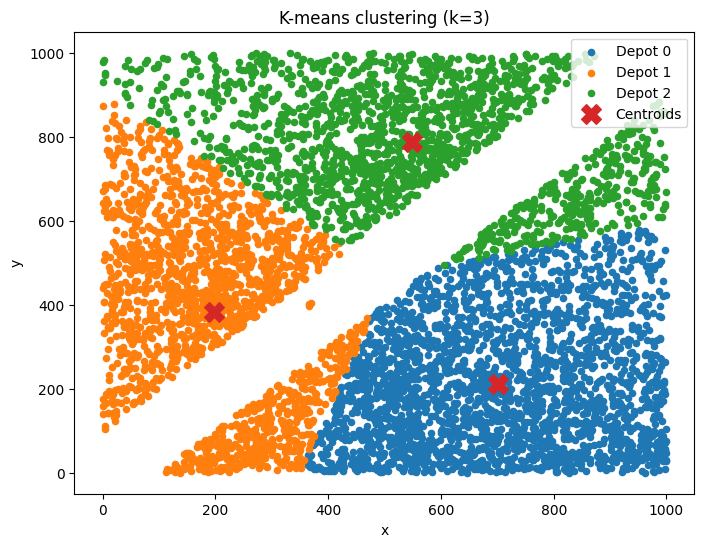

In [203]:
plt.figure(figsize=(8, 6))

for depot in range(N_DEPOTS):
    cluster_points = df_loc_kmeans[df_loc_kmeans["depot_id"] == depot]
    plt.scatter(cluster_points["x"], cluster_points["y"], s=20, label=f"Depot {depot}")

plt.scatter(
    centers_kmeans[:, 0],
    centers_kmeans[:, 1],
    marker="X",
    s=200,
    label="Centroids"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"K-means clustering (k={N_DEPOTS})")
plt.legend()
plt.show()

K-means jakoi asiakkaat kolmeen alueelliseen ryhmään ja tuotti centroidit. Centroidit voidaan tulkita kolmen depotin ehdotetuiksi sijainneiksi, koska ne kuvaavat klusterin “keskikohtaa”. Visualisointi tukee tätä: asiakkaat muodostavat selkeitä ryhmiä depotien ympärille.

### Osa 1B

Laskemme WCSS-arvon (inertia) k:n arvoille 1–10 ja piirrämme elbow-kuvaajan.
Tämä auttaa tunnistamaan kohdan, jonka jälkeen klusterien määrän kasvattaminen ei enää paranna tulosta merkittävästi.

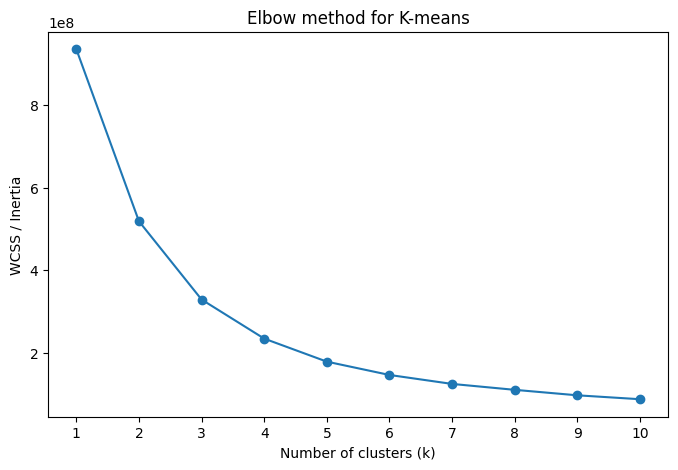

WCSS values:
k=1: 935060769.761
k=2: 518436094.570
k=3: 328935427.524
k=4: 234343650.784
k=5: 178583472.012
k=6: 146336764.496
k=7: 124637710.849
k=8: 110328983.506
k=9: 97080041.400
k=10: 87600920.583


In [204]:
wcss = []
k_values = range(1, 11)

for k in k_values:
    km = KMeans(n_clusters=k, init="random", random_state=RANDOM_STATE)
    km.fit(X_locations)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), wcss, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow method for K-means")
plt.xticks(list(k_values))
plt.show()

print("WCSS values:")
for k, val in zip(k_values, wcss):
    print(f"k={k}: {val:.3f}")

Laskemme silhouette score -arvon k:n arvoille 2–10 ja piirrämme kuvaajan.
Mitä korkeampi silhouette-arvo, sitä paremmin klusterit erottuvat toisistaan - näin voidaan vertailla eri k-vaihtoehtoja.

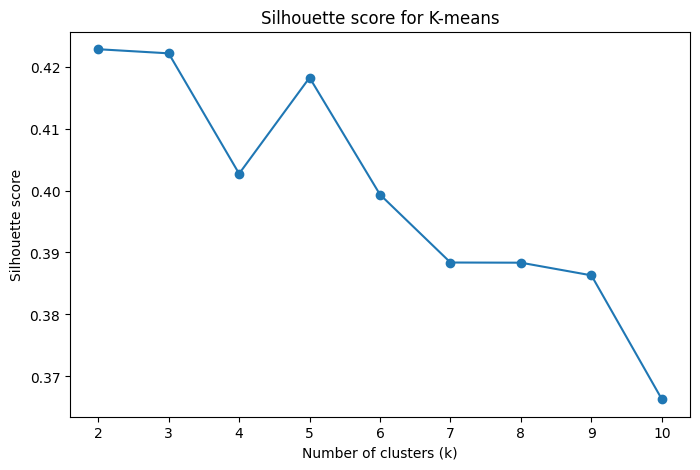

Silhouette scores:
k=2: 0.4228
k=3: 0.4221
k=4: 0.4027
k=5: 0.4182
k=6: 0.3993
k=7: 0.3884
k=8: 0.3884
k=9: 0.3863
k=10: 0.3663


In [205]:
sil_scores = []
sil_k_values = range(2, 11)

for k in sil_k_values:
    km = KMeans(n_clusters=k, init="random", random_state=RANDOM_STATE)
    labels = km.fit_predict(X_locations)
    score = silhouette_score(X_locations, labels)
    sil_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(list(sil_k_values), sil_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score for K-means")
plt.xticks(list(sil_k_values))
plt.show()

print("Silhouette scores:")
for k, score in zip(sil_k_values, sil_scores):
    print(f"k={k}: {score:.4f}")

Elbow-kuvaajassa WCSS pienenee voimakkaasti välillä k=1 → k=3 ja sen jälkeen lasku hidastuu, mikä viittaa kyynärpäähän noin kohdassa k≈3–4.  
Silhouette-arvo on korkein k=2 (0.4228) ja lähes sama k=3 (0.4221), minkä jälkeen se pääosin laskee. Tehtävän kannalta k=3 on järkevä kompromissi: hyvä laatu ja käytännöllinen depot-määrä.

### Osa 1C

Toistamme k-means-klusteroinnin arvolla k=10, jotta nähdään, miten tulos muuttuu, kun depot-määrä kasvaa.
Samalla mittaamme suoritusaikaa arvioidaksemme laskennan kuormittavuutta.

In [206]:
K_TEST = 10

start = time.perf_counter()

kmeans_10 = KMeans(
    n_clusters=K_TEST,
    init="random",
    random_state=RANDOM_STATE
)
labels_10 = kmeans_10.fit_predict(X_locations)
centers_10 = kmeans_10.cluster_centers_

elapsed = time.perf_counter() - start

print(f"K-means with k={K_TEST} finished in {elapsed:.6f} seconds")
print("Centers (first rows):")
print(centers_10[:5])

K-means with k=10 finished in 0.106779 seconds
Centers (first rows):
[[881.10218422 635.21820804]
 [452.0773205  767.46252873]
 [732.73746126 401.79973121]
 [308.10079757  87.32225671]
 [849.63070889 128.41204786]]


Piirrämme kuvaajan tapaukselle k=10: asiakkaat väritettyinä + keskipisteet X-merkillä.
Vertaamme tulosta tapaukseen k=3: suuremmalla k-arvolla klusterit ovat pienempiä ja paikallisempia.

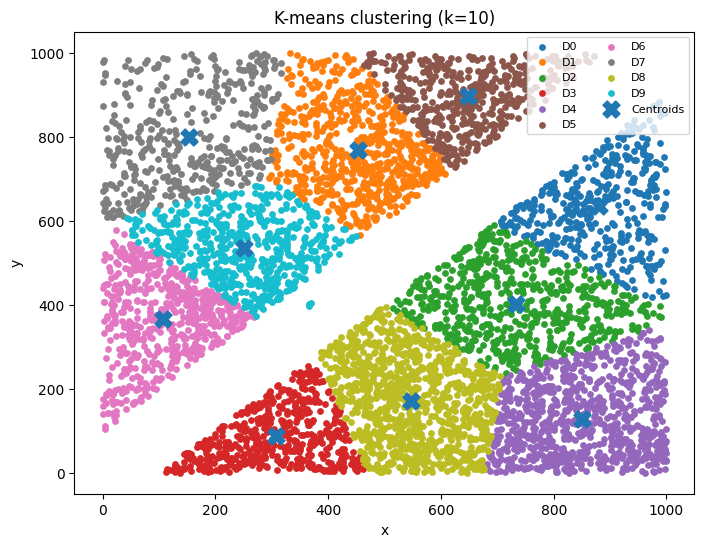

In [207]:
df_loc_k10 = df_loc.copy()
df_loc_k10["depot_id"] = labels_10

plt.figure(figsize=(8, 6))

for depot in range(K_TEST):
    cluster_points = df_loc_k10[df_loc_k10["depot_id"] == depot]
    plt.scatter(cluster_points["x"], cluster_points["y"], s=15, label=f"D{depot}")

plt.scatter(
    centers_10[:, 0],
    centers_10[:, 1],
    marker="X",
    s=150,
    label="Centroids"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"K-means clustering (k={K_TEST})")
plt.legend(ncol=2, fontsize=8)
plt.show()

Kun depotien määrä kasvatettiin k=10:een, klusterit muuttuivat pienemmiksi ja paikallisemmiksi ja centroidit jakautuivat tiheämmin alueelle. Tämä voi pienentää etäisyyttä lähimpään depottiin.  
Laskenta-aika oli noin 0.17 s, joten malli toimii nopeasti myös suuremmalla klusterimäärällä tässä aineistossa.

### Osa 1D

Suoritamme AgglomerativeClustering-menetelmän käyttäen arvoa N_DEPOTS, jotta saamme vaihtoehtoisen jaon asiakkaista.
Tulokset tallennetaan sarakkeeseen cluster_id.

In [208]:
agg = AgglomerativeClustering(n_clusters=N_DEPOTS)
labels_agg = agg.fit_predict(X_locations)

df_loc_agg = df_loc.copy()
df_loc_agg["cluster_id"] = labels_agg

print("Agglomerative clustering fitted.")
display(df_loc_agg.head(10))

Agglomerative clustering fitted.


,clientid,x,y,cluster_id
0,1,622.771572,164.857623,0
1,2,416.357298,630.193634,2
2,3,292.735020,567.333231,2
3,4,737.211288,166.225676,0
4,5,540.475375,682.912298,1
5,6,535.469492,318.439661,0
6,7,640.380050,870.833221,1
7,8,235.772075,359.048203,2
8,9,481.896884,661.491838,2
9,10,730.032789,312.177817,0


Piirrämme scatterplotin cluster_id-arvon mukaan ja vertaamme visuaalisesti k-means-tulokseen samalla k-arvolla.

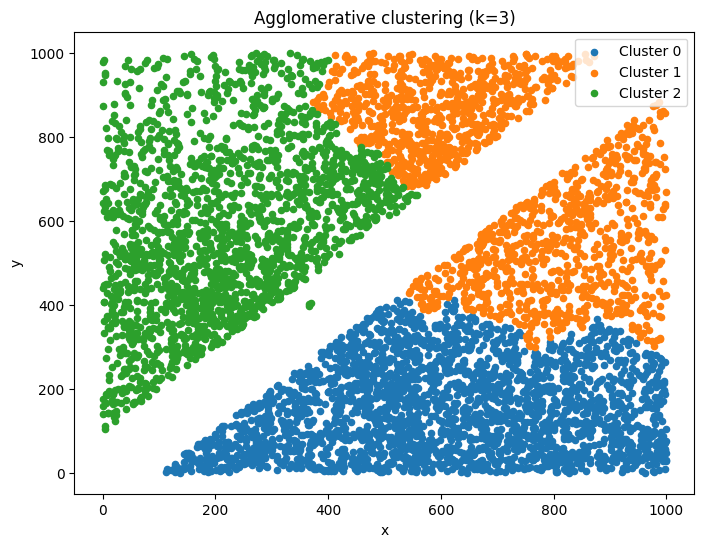

In [209]:
plt.figure(figsize=(8, 6))

for cl in range(N_DEPOTS):
    cluster_points = df_loc_agg[df_loc_agg["cluster_id"] == cl]
    plt.scatter(cluster_points["x"], cluster_points["y"], s=20, label=f"Cluster {cl}")

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Agglomerative clustering (k={N_DEPOTS})")
plt.legend()
plt.show()

Koska agglomerative-menetelmä ei tuota keskipisteitä suoraan, laskemme jokaiselle klusterille x- ja y-koordinaattien keskiarvot.
Näitä pisteitä voidaan käyttää arvioituina depot-sijainteina ja verrata k-meansin centroid-pisteisiin.

In [210]:
agg_cluster_means = (
    df_loc_agg.groupby("cluster_id")[["x", "y"]]
    .mean()
    .reset_index()
    .sort_values("cluster_id")
)

print("Agglomerative cluster mean coordinates (depot-like reference points):")
display(agg_cluster_means)

Agglomerative cluster mean coordinates (depot-like reference points):


,cluster_id,x,y
0,0,607.735321,151.226451
1,1,709.978549,687.401536
2,2,218.178835,578.471885


Vertaamme k-means- ja agglomerative-menetelmien suoritusaikoja samalla k-arvolla.
Tämä osoittaa, kumpi menetelmä on nopeampi kyseisellä datasetillä.

In [211]:
start = time.perf_counter()
_ = KMeans(n_clusters=N_DEPOTS, init="random", random_state=RANDOM_STATE).fit(X_locations)
kmeans_time = time.perf_counter() - start

start = time.perf_counter()
_ = AgglomerativeClustering(n_clusters=N_DEPOTS).fit(X_locations)
agg_time = time.perf_counter() - start

print(f"K-means time (k={N_DEPOTS}):        {kmeans_time:.6f} s")
print(f"Agglomerative time (k={N_DEPOTS}): {agg_time:.6f} s")

K-means time (k=3):        0.033959 s
Agglomerative time (k=3): 0.712173 s


Agglomerative clustering jakoi asiakkaat myös kolmeen ryhmään, mutta se ei tuota centroidteja suoraan, joten “depot-pisteitä” arvioitiin klusterien keskiarvokoordinaateilla.  
Aikavertailussa k-means oli selvästi nopeampi (~0.11 s) kuin agglomerative (~1.54 s), joten k-means on käytännöllisempi depotien sijoitteluun, etenkin isommalla datalla.

Testattiin k-means ja agglomerative depotien sijoitteluun. K-means on käytännöllinen, koska centroidit saadaan suoraan ja laskenta on nopeaa. Elbow- ja silhouette-tulokset tukevat sitä, että k noin 3–4 on järkevä alue, ja kokeilu k=10 näyttää, miten suurempi depot-määrä tekee palvelualueista paikallisempia.

## Osa 2

Suoritamme Apriori-algoritmin löytääksemme yleisimmät tuoteryhmien yhdistelmät (frequent itemsets).
MIN_SUPPORT määrittää vähimmäistiheyden, jolla yhdistelmän tulee esiintyä transaktioissa.
Parametri use_colnames=True säilyttää sarakenimet tuloksissa.
Lisäämme sarakkeen length, jotta voimme tarkastella erikseen yksittäisiä tuotteita, pareja jne.

In [212]:
MIN_SUPPORT = 0.05

frequent_itemsets = apriori(
    df_prod_apr,
    min_support=MIN_SUPPORT,
    use_colnames=True
)

frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)

print("Frequent itemsets shape:", frequent_itemsets.shape)
display(frequent_itemsets.sort_values("support", ascending=False).head(20))

Frequent itemsets shape: (19, 3)


,support,itemsets,length
14,0.20626,(Prod19),1
5,0.19853,(Prod9),1
4,0.16179,(Prod8),1
8,0.15971,(Prod12),1
15,0.14798,(Prod20),1
9,0.14557,(Prod14),1
3,0.13499,(Prod7),1
18,0.13476,"(Prod19, Prod20)",2
11,0.13100,(Prod16),1
1,0.13098,(Prod2),1


Arvolla MIN_SUPPORT = 0.05 löytyi 19 yhdistelmää. Lähes kaikki ovat yksittäisiä tuotteita, pareja on vain vähän.
Tämä on odotettavaa: yhteisostot ovat yleensä harvinaisempia kuin yksittäiset ostot.

Tarkastelemme, kuinka monta eri pituista yhdistelmää (1, 2, …) löytyi.
Tulostamme erikseen yhdistelmät, joiden pituus ≥ 2, jotta näemme erityisesti parit ja muut yhdistelmät - nämä ovat yleensä kiinnostavimpia sääntöjen kannalta.

In [213]:
print("Itemset lengths:")
print(frequent_itemsets["length"].value_counts().sort_index())

display(
    frequent_itemsets[frequent_itemsets["length"] >= 2]
    .sort_values("support", ascending=False)
    .head(20)
)

Itemset lengths:
length
1    16
2     3
Name: count, dtype: int64


,support,itemsets,length
18,0.13476,"(Prod19, Prod20)",2
17,0.11145,"(Prod15, Prod9)",2
16,0.06683,"(Prod5, Prod12)",2


Frequent itemset -tulosten pohjalta muodostamme assosiaatiosäännöt käyttäen association_rules-funktiota.
Käytämme mittarina confidence-arvoa, ja MIN_CONFIDENCE määrittää säännön vähimmäisluotettavuuden.
Tuloksena saadaan taulukko, joka sisältää muun muassa support-, confidence- ja lift-arvot.

In [214]:
MIN_CONFIDENCE = 0.5

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=MIN_CONFIDENCE
)

print("Rules shape:", rules.shape)
display(rules.head(10))

Rules shape: (5, 14)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Prod5),(Prod12),0.10459,0.15971,0.06683,0.638971,4.000822,1.0,0.050126,2.327488,0.837662,0.338431,0.570352,0.528709
1,(Prod15),(Prod9),0.11880,0.19853,0.11145,0.938131,4.725388,1.0,0.087865,12.954372,0.894663,0.541335,0.922806,0.749754
2,(Prod9),(Prod15),0.19853,0.11880,0.11145,0.561376,4.725388,1.0,0.087865,2.009011,0.983664,0.541335,0.502243,0.749754
3,(Prod19),(Prod20),0.20626,0.14798,0.13476,0.653350,4.415125,1.0,0.104238,2.457869,0.974508,0.613997,0.593144,0.782007
4,(Prod20),(Prod19),0.14798,0.20626,0.13476,0.910664,4.415125,1.0,0.104238,8.884845,0.907849,0.613997,0.887449,0.782007


Taulukossa säännöt esitetään muodossa frozenset, mikä ei ole kovin luettava.
Siksi teemme kopion nimeltä rules_view ja muutamme antecedents- ja consequents-kentät tavallisiksi merkkijonoiksi.
Säilytämme keskeiset mittarit (support, confidence, lift) ja lajittelemme tulokset, jotta vahvimmat säännöt näkyvät heti.

In [215]:
rules_view = rules.copy()

rules_view["antecedents_str"] = rules_view["antecedents"].apply(lambda x: ", ".join(sorted(list(x))))
rules_view["consequents_str"] = rules_view["consequents"].apply(lambda x: ", ".join(sorted(list(x))))

cols_to_show = [
    "antecedents_str",
    "consequents_str",
    "support",
    "confidence",
    "lift"
]

display(
    rules_view[cols_to_show]
    .sort_values(["confidence", "lift"], ascending=False)
    .head(20)
)

,antecedents_str,consequents_str,support,confidence,lift
1,Prod15,Prod9,0.11145,0.938131,4.725388
4,Prod20,Prod19,0.13476,0.910664,4.415125
3,Prod19,Prod20,0.13476,0.653350,4.415125
0,Prod5,Prod12,0.06683,0.638971,4.000822
2,Prod9,Prod15,0.11145,0.561376,4.725388


MIN_SUPPORT=0.05 tuotti 16 yksittäistä itemsetiä ja 3 paria, eli hyvin yleisiä yhteisostoja löytyi vain muutamia tällä rajalla.  
Näistä muodostettiin 5 sääntöä, kun MIN_CONFIDENCE=0.5. Vahvimmat säännöt ovat sekä luotettavia (korkea confidence) että vahvoja (lift > 4), mikä viittaa selkeään yhteisostamiseen. Tällaisia sääntöjä voi hyödyntää suosituksissa ja cross-sellissä.

Lajittelemme säännöt confidence-arvon mukaan laskevasti.
Näin nähdään, kuinka usein sääntö “toimii”: jos antecedent ostetaan, kuinka todennäköisesti myös consequent ostetaan.

In [216]:
top_conf_rules = (
    rules_view[cols_to_show]
    .sort_values("confidence", ascending=False)
    .reset_index(drop=True)
)

print("Top rules by confidence:")
display(top_conf_rules.head(10))

Top rules by confidence:


,antecedents_str,consequents_str,support,confidence,lift
0,Prod15,Prod9,0.11145,0.938131,4.725388
1,Prod20,Prod19,0.13476,0.910664,4.415125
2,Prod19,Prod20,0.13476,0.653350,4.415125
3,Prod5,Prod12,0.06683,0.638971,4.000822
4,Prod9,Prod15,0.11145,0.561376,4.725388


Lajittelemme säännöt lift-arvon mukaan laskevasti.
Lift kuvaa yhteyden vahvuutta: jos lift > 1, tuotteet esiintyvät yhdessä useammin kuin satunnaisesti voisi odottaa. Mitä suurempi lift, sitä vahvempi yhteys.

In [217]:
top_lift_rules = (
    rules_view[cols_to_show]
    .sort_values("lift", ascending=False)
    .reset_index(drop=True)
)

print("Top rules by lift:")
display(top_lift_rules.head(10))

Top rules by lift:


,antecedents_str,consequents_str,support,confidence,lift
0,Prod15,Prod9,0.11145,0.938131,4.725388
1,Prod9,Prod15,0.11145,0.561376,4.725388
2,Prod19,Prod20,0.13476,0.653350,4.415125
3,Prod20,Prod19,0.13476,0.910664,4.415125
4,Prod5,Prod12,0.06683,0.638971,4.000822


Suodatamme säännöt kahdella ehdolla: confidence ≥ 0.6 ja lift > 1.
Tämä poistaa heikot tai satunnaiset yhteydet ja jättää jäljelle luotettavammat säännöt.
Lopuksi lajittelemme tulokset lift- ja confidence-arvojen mukaan, jotta vahvimmat säännöt ovat ylimpänä.

In [218]:
rules_strong = rules_view[
    (rules_view["confidence"] >= 0.6) &
    (rules_view["lift"] > 1.0)
][cols_to_show].sort_values(["lift", "confidence"], ascending=False)

print("Stronger rules (confidence >= 0.6 and lift > 1):")
display(rules_strong.head(20))
print("Count:", len(rules_strong))

Stronger rules (confidence >= 0.6 and lift > 1):


,antecedents_str,consequents_str,support,confidence,lift
1,Prod15,Prod9,0.11145,0.938131,4.725388
4,Prod20,Prod19,0.13476,0.910664,4.415125
3,Prod19,Prod20,0.13476,0.653350,4.415125
0,Prod5,Prod12,0.06683,0.638971,4.000822


Count: 4


Säännöt järjestettiin confidence- ja lift-mittareiden mukaan, jolloin löytyivät selkeimmät yhteydet.  
Kun suodatettiin confidence ≥ 0.6 ja lift > 1, jäi 4 sääntöä. Kaikilla näillä lift on yli 4, joten yhteys on selvästi vahvempi kuin satunnainen. Nämä ovat parhaat ehdokkaat käytännön suosituksiin.

Mallinnuksessa ratkaistiin kaksi tehtävää: depotien sijoittelu ja tuoteryhmien yhteydet. Depotien sijoittelussa käytettiin k-means ja agglomerative -menetelmiä ja vertailtiin sekä laatua (elbow/silhouette) että suoritusaikaa. Ostodatan analyysissä käytettiin Apriori-algoritmia ja assosiaatiosääntöjä, ja lopuksi poimittiin vahvimmat säännöt confidence- ja lift-mittareilla. Seuraavaksi tuloksia arvioidaan ja niistä tehdään suositukset.

# 5. Evaluation

## Osa 1: Depot placement (clustering)

Testattiin kahta tapaa ryhmitellä asiakassijainnit: k-means ja agglomerative.

- **K-means (k=3)** jakoi asiakkaat kolmeen ryhmään ja antoi centroidit. Centroidit ovat käteviä, koska ne voidaan ottaa suoraan depotien likimääräisiksi sijainneiksi.
- **Elbow**: WCSS pieneni selvästi välillä k=1 → k=3 ja sen jälkeen parannus hidastui, joten k≈3–4 näyttää järkevältä alueelta.
- **Silhouette**: paras arvo oli k=2 (0.4228), mutta k=3 oli lähes sama (0.4221). Tämä tukee sitä, että k=3 toimii hyvin käytännössä.
- **Kokeilu k=10**: klusterit muuttuivat pienemmiksi ja paikallisemmiksi, ja centroidit jakautuivat tiheämmin alueelle. Ajoaika oli silti lyhyt (~0.17 s).
- **Agglomerative (k=3)** antoi myös kolmen ryhmän jaon, mutta centroidteja ei tule suoraan, joten “depot-pisteet” arvioitiin klusterien keskiarvoilla. Se oli myös selvästi hitaampi (~1.54 s) kuin k-means (~0.11 s).

**Yhteenveto:** k-means sopii paremmin tähän käyttöön, koska centroidit saadaan suoraan ja laskenta on nopeaa. Depotien määrä on kompromissi: pienempi k = yksinkertaisempi verkosto, suurempi k = paikallisemmat palvelualueet.

    Valitsimme tässä työssä perusvaihtoehdoksi k=3, koska se on käytännöllinen kompromissi. Silhouette-arvo on lähes sama k=2 (0.4228) ja k=3 (0.4221), mutta elbow/ WCSS paranee selvästi vielä k=3 asti. k=4 ei enää parantanut tulosta samalla tavalla (silhouette laski 0.4027), joten k=3 oli tässä aineistossa järkevä “keskitie”.
---

## Osa 2: Product group associations (association rule mining)

Tuoteryhmien yhteyksiä etsittiin Apriori + association rules -menetelmällä.

- `MIN_SUPPORT = 0.05` antoi 19 itemsetiä (16 yksittäistä ja 3 paria).
- `MIN_CONFIDENCE = 0.5` antoi 5 sääntöä.
- Vahvimmat säännöt erottuivat sillä, että confidence oli korkea ja lift oli selvästi > 1 (tässä tapauksessa > 4), eli yhteys ei näytä satunnaiselta.

Esimerkkejä vahvoista säännöistä:
- Prod15 → Prod9 (confidence ≈ 0.94, lift ≈ 4.73)
- Prod20 → Prod19 (confidence ≈ 0.91, lift ≈ 4.42)
- Prod5 → Prod12 (confidence ≈ 0.64, lift ≈ 4.00)

**Yhteenveto:** löytyi muutamia selkeitä sääntöjä, joita voi käyttää suosituksiin ja cross-sell-ehdotuksiin.

# 6. Deployment / Recommendations

## Depotit (clustering)

- Käytännössä helpoin tapa aloittaa on **k-means**, koska se antaa centroidit suoraan ja toimii nopeasti.
- Centroidit voidaan ottaa **depotien likimääräisiksi sijainneiksi** (2D-tasossa).
- Depotien määrä on kompromissi:
  - **k=3** = yksinkertainen verkosto
  - **k=10** = paikallisemmat alueet ja tiheämpi verkosto
- Elbow- ja silhouette-kuvaajia voi käyttää apuna, kun vertaillaan eri k-arvoja.

## Tuotesuositukset (association rules)

- Vahvimpia sääntöjä voi käyttää suosituksissa muodossa: **“Jos ostetaan X, suosittele Y”**.
- Paras käytäntö on painottaa sääntöjä, joilla on:
  - korkea **confidence**
  - **lift > 1** (mielellään selvästi > 1)

Esimerkkejä tämän aineiston säännöistä:
- Prod15 → Prod9
- Prod20 → Prod19
- Prod5 → Prod12

## Rajoitteet

- Klusterointi käyttää vain 2D-koordinaatteja, eikä huomioi reittejä, säätä tai dronejen rajoitteita.
- Assosiaatiosäännöt perustuvat binääriseen dataan (ostettu/ei ostettu), joten määrät, hinnat ja ajallinen järjestys eivät näy mukana.
- Tuloksia kannattaa käyttää suuntaa-antavasti ja tarkistaa käytännössä, toimiiko valittu depot-määrä ja parantavatko suositukset lisämyyntiä.